# Models, Context, Tools and Skills

Notebook 01 showed that the machinery around a model decides the result: the same model could not answer a question about this repository with a bare prompt, nor with a better prompt, and answered it with a cited file once a loop gave it two tools. This notebook opens the first four pieces of that machinery one at a time, on the official Anthropic Python SDK and real Claude models. Nothing here is simulated: every number printed below comes from the call above it.

- The **model** sits behind one request and one response; you choose it by capability, cost and latency.
- The **context** is everything the model sees in one call, and it is a budget, not a bucket.
- **Tools** are functions the model can ask for, and how you describe them is prompt engineering for machines.
- **Skills** are folders of instructions the agent opens only when a task needs them.

**What you will learn**

- What a request to a model and its response look like, and how three Claude models differ on the same task
- How to count tokens before you spend them, watch a session grow, compact it the real way and keep notes outside the window
- How a tool becomes a JSON schema, why a vague description hurts, how errors and permissions belong to the interface
- How progressive disclosure keeps a library of skills almost free until one is needed, measured on the real tokenizer

In the car metaphor of this module: the model is the engine, the context is the dashboard, tools are the steering and the pedals, skills are the manuals in the glovebox.

## How to run this notebook

- **Locally with Jupyter:** open it in Jupyter, JupyterLab or VS Code and run the cells top to bottom from this folder.
- **On Google Colab:** upload the file (File > Upload notebook). The setup cell downloads the handful of repository files the tools read.

**The key.** The notebook talks to real Claude models, so it needs an `ANTHROPIC_API_KEY`. The setup cell looks in three places and stops at the first hit: the git-ignored `.env` at the repository root (locally, copy `.env.example` to `.env` and put the key there), then the `ANTHROPIC_API_KEY` environment variable (how the repository's CI passes its secret), then the Colab Secrets panel (the key icon on the left, same name). Whatever the source, the key is read with `python-dotenv` or plain `os.environ` and handed to the client explicitly; the notebook never exports it. Never paste a key into a cell: the repository's checks reject notebooks that contain anything that looks like one, and this notebook never prints it.

**Money.** Real calls cost money and vary between runs. One full execution of this notebook costs well under 2 USD (the last cell prints the exact amount for the run you are reading). Where the text quotes a number, it is the number of the run recorded here; your run will differ a little.

In [1]:
# Setup 1/2: packages, repository root, API key, client.
import importlib.util
import os
import subprocess
import sys
from pathlib import Path

for package, module in [("anthropic", "anthropic"), ("python-dotenv", "dotenv"), ("pyyaml", "yaml")]:
    if importlib.util.find_spec(module) is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])

import anthropic
from dotenv import dotenv_values


def find_repo_root(start: Path) -> Path | None:
    # Walk up until a folder holds README.md and the module folder: that is the repository root.
    for candidate in [start, *start.parents]:
        if (candidate / "README.md").exists() and (candidate / "M5 - Harness Engineering").is_dir():
            return candidate
    return None


REPO_ROOT = find_repo_root(Path.cwd().resolve())

# On Colab the repository is not there: download the files this notebook reads into repo/ (one list, kept here).
COLAB_FILES = [
    "README.md", "LICENSE", "CHANGELOG.md", "requirements.txt",
    ".github/workflows/notebooks.yml", "docs/data/model.json",
    "M5 - Harness Engineering/README.md",
    "M5 - Harness Engineering/lab/CLAUDE.md",
    "M5 - Harness Engineering/lab/.claude/skills/repo-answers/SKILL.md",
    "M5 - Harness Engineering/lab/.claude/skills/explain-term/SKILL.md",
]
if REPO_ROOT is None:
    import urllib.parse
    import urllib.request
    base = "https://raw.githubusercontent.com/maglionejm/fontys-tech-exercises/main/"
    REPO_ROOT = Path("repo").resolve()
    for rel in COLAB_FILES:
        target = REPO_ROOT / rel
        target.parent.mkdir(parents=True, exist_ok=True)
        urllib.request.urlretrieve(base + urllib.parse.quote(rel), target)
    print(f"Downloaded {len(COLAB_FILES)} repository files into repo/")


def load_api_key() -> tuple[str | None, str]:
    # Resolution order, first hit wins: the repository .env, then the process environment
    # (how CI passes the repository secret), then the Colab Secrets panel.
    key = dotenv_values(REPO_ROOT / ".env").get("ANTHROPIC_API_KEY")
    if key:
        return key, ".env at the repository root"
    key = os.environ.get("ANTHROPIC_API_KEY")
    if key:
        return key, "the ANTHROPIC_API_KEY environment variable"
    try:
        from google.colab import userdata  # type: ignore
        key = userdata.get("ANTHROPIC_API_KEY")
        if key:
            return key, "the Colab Secrets panel"
    except Exception:
        pass
    return None, "nowhere"


api_key, key_source = load_api_key()
if not api_key:
    raise SystemExit("No ANTHROPIC_API_KEY found: copy .env.example to .env at the repository root and put your key there (in CI, set the ANTHROPIC_API_KEY repository secret; on Colab, add it in the Secrets panel), then run this cell again.")

client = anthropic.Anthropic(api_key=api_key)   # passed explicitly; never exported into the environment
del api_key
print(f"Client ready (anthropic {anthropic.__version__}). Key loaded from {key_source}; it is never printed.")

Client ready (anthropic 1.9.0). Key loaded from .env at the repository root; it is never printed.


In [2]:
# Setup 2/2: the constants and helpers every section shares.
import json
import time
from dataclasses import dataclass

import matplotlib.pyplot as plt
import pandas as pd

MAIN_MODEL = "claude-opus-5"      # main agents
WORKER_MODEL = "claude-sonnet-5"  # workers, judges, summarizers
SMALL_MODEL = "claude-haiku-4-5"  # the third model of the comparison

# USD per million tokens: (input, output). Cache reads cost one tenth of input, cache writes 1.25 times input.
PRICES = {MAIN_MODEL: (5.00, 25.00), WORKER_MODEL: (2.00, 10.00), SMALL_MODEL: (1.00, 5.00)}


def cost_usd(usage, model: str) -> float:
    price_in, price_out = PRICES[model]
    cached_read = usage.cache_read_input_tokens or 0
    cached_write = usage.cache_creation_input_tokens or 0
    return (usage.input_tokens * price_in + cached_read * price_in * 0.1
            + cached_write * price_in * 1.25 + usage.output_tokens * price_out) / 1_000_000


LEDGER = []  # (model, usage) for every call this notebook makes; the last cell adds it up


def call_model(**kwargs):
    # The one place this notebook calls the API, so that every call is counted.
    response = client.messages.create(**kwargs)
    LEDGER.append((kwargs["model"], response.usage))
    return response


def text_of(response) -> str:
    return "".join(block.text for block in response.content if block.type == "text").strip()


def show_usage(response, model: str) -> None:
    u = response.usage
    print(f"usage: {u.input_tokens:,} input tokens, {u.output_tokens:,} output tokens, "
          f"stop_reason={response.stop_reason!r}, cost {cost_usd(u, model):.4f} USD")


def barh(labels, values, title, xlabel, fmt="{:,.0f}"):
    fig, ax = plt.subplots(figsize=(8.5, 0.5 * len(labels) + 1.3))
    bars = ax.barh(list(labels), list(values), color="#1E5EF3")
    ax.invert_yaxis()
    ax.set_xlabel(xlabel)
    ax.set_title(title, loc="left")
    for bar, value in zip(bars, values):
        ax.text(bar.get_width(), bar.get_y() + bar.get_height() / 2, " " + fmt.format(value), va="center")
    ax.spines[["top", "right"]].set_visible(False)
    ax.margins(x=0.18)
    plt.tight_layout()
    plt.show()


RECORD = {}  # a few numbers the notebook's own text quotes; written to a scratch file for the author


def record(key, value):
    RECORD[key] = value
    Path(__import__("tempfile").gettempdir(), "nb02_numbers.json").write_text(json.dumps(RECORD, indent=1, default=str))


print("Helpers ready:", ", ".join(["cost_usd", "call_model", "text_of", "show_usage", "barh"]))

Helpers ready: cost_usd, call_model, text_of, show_usage, barh


### The two tools and the loop from notebook 01

Notebook 01 ended with a manual loop of about forty lines around two read-only tools that look at this very repository: `list_files` and `read_file`. Every section below needs them, so here they are again in compact form. Three details matter for this notebook:

- **Guardrails live in the tool code.** Both tools refuse paths that escape the repository root, paths inside `.git`, `.venv` and `.claude`, and any file named `.env` or ending in `.env`. That refusal is a guardrail: it works whatever the model asks for, because it runs in your code, not in the model.
- **Failures become messages.** A tool that cannot do its job raises `ValueError` with a sentence the model can act on. The loop turns that into a `tool_result` with `is_error: True` (section 3 looks at this closely).
- **Results are capped.** `read_file` returns at most 12,000 characters and says when it truncated, because every character it returns stays in the context for the rest of the session (section 2 measures that).

In [3]:
from typing import NamedTuple, Callable

BLOCKED_FOLDERS = {".git", ".venv", ".claude"}
MAX_CHARS = 12_000


def is_secret_name(name: str) -> bool:
    return name == ".env" or name.endswith(".env")


def is_hidden(name: str) -> bool:
    # Local scratch that is not part of the repository: dot-files (except .github), caches, editor leftovers.
    return (name.startswith(".") and name != ".github") or name in {"__pycache__", ".ipynb_checkpoints"} or name.startswith(".codex-")


def safe_path(path: str) -> Path:
    root = REPO_ROOT.resolve()
    target = (root / path).resolve()
    if target != root and root not in target.parents:
        raise ValueError(f"{path!r} points outside the repository; use a path relative to the repository root, for example README.md")
    if any(part in BLOCKED_FOLDERS for part in target.relative_to(root).parts):
        raise ValueError(f"{path!r} is inside a folder this tool does not open (.git, .venv, .claude)")
    if is_secret_name(target.name):
        raise ValueError(f"{path!r} is a credentials file; this tool never opens .env files")
    return target


def list_files(folder: str = ".") -> str:
    target = safe_path(folder)
    if not target.is_dir():
        raise ValueError(f"{folder!r} is not a folder of the repository; try '.' for the root")
    names = sorted(p.name + ("/" if p.is_dir() else "") for p in target.iterdir()
                   if not is_hidden(p.name) and not is_secret_name(p.name))
    return "\n".join(names) or "(empty folder)"


def read_file(path: str) -> str:
    target = safe_path(path)
    if not target.is_file():
        raise ValueError(f"{path!r} does not exist; call list_files on its folder to see the real names")
    try:
        text = target.read_text(encoding="utf-8")
    except UnicodeDecodeError:
        raise ValueError(f"{path!r} is not a text file") from None
    if len(text) > MAX_CHARS:
        text = text[:MAX_CHARS] + f"\n[truncated: {len(text) - MAX_CHARS:,} more characters; this tool returns at most {MAX_CHARS:,}]"
    return text


class Tool(NamedTuple):
    schema: dict      # what the model reads: name, description, input_schema
    fn: Callable      # what your code runs


LIST_FILES = Tool({
    "name": "list_files",
    "description": "List the names of files and folders directly under one folder of the course repository. Hidden folders and local scratch (dot-files other than .github, caches) are not listed. Call it first when you do not know which file holds the answer. Folder names end with '/'.",
    "input_schema": {"type": "object",
                     "properties": {"folder": {"type": "string", "description": "Repository-relative folder path, for example '.' for the root or '.github/workflows'"}},
                     "required": ["folder"]},
}, list_files)

READ_FILE = Tool({
    "name": "read_file",
    "description": "Return the text of one file of the course repository (text files only, at most 12,000 characters). Call it to check a fact instead of guessing, then cite the path in your answer.",
    "input_schema": {"type": "object",
                     "properties": {"path": {"type": "string", "description": "Repository-relative file path, for example 'README.md' or '.github/workflows/notebooks.yml'"}},
                     "required": ["path"]},
}, read_file)

print(list_files("."))
print("---")
print(read_file("LICENSE")[:120], "...")

.github/
CHANGELOG.md
CODE_OF_CONDUCT.md
CONTRIBUTING.md
LICENSE
M1 - Descriptive analytics/
M2 - Machine Learning/
M3 - ML Architectures and Deployment/
M5 - Harness Engineering/
Makefile
README.md
SECURITY.md
docs/
presentations/
requirements-dev.txt
requirements.txt
ruff.toml
scripts/
---
MIT License

Copyright (c) 2026 Juan Martin Maglione

Permission is hereby granted, free of charge, to any person obtain ...


In [4]:
SYSTEM = (
    "You answer questions about the course repository 'fontys-tech-exercises' using the tools. "
    "Check facts in files before answering and quote the exact value. End with 'Source: <path>' naming each file you used. "
    "If the repository does not contain the answer, say so plainly and do not guess."
)


@dataclass
class RunResult:
    answer: str
    messages: list
    usages: list                 # one usage object per model call
    tool_calls: list             # (turn, tool name, input, status) with status ok | error | denied
    stopped_because: str         # end_turn | max_tokens | refusal | max_turns
    model: str
    seconds: float = 0.0

    @property
    def turns(self) -> int:
        return len(self.usages)

    @property
    def input_tokens(self) -> int:
        return sum(u.input_tokens + (u.cache_read_input_tokens or 0) + (u.cache_creation_input_tokens or 0) for u in self.usages)

    @property
    def output_tokens(self) -> int:
        return sum(u.output_tokens for u in self.usages)

    @property
    def cost(self) -> float:
        return sum(cost_usd(u, self.model) for u in self.usages)

    def summary(self) -> str:
        return (f"{self.turns} model calls | {len(self.tool_calls)} tool calls | {self.input_tokens:,} in / {self.output_tokens:,} out "
                f"| {self.cost:.4f} USD | {self.seconds:.1f} s | stopped: {self.stopped_because}")


def run_agent(question, tools, *, system=SYSTEM, model=MAIN_MODEL, history=None,
              max_turns=6, effort="medium", max_tokens=2000, gate=None, verbose=True) -> RunResult:
    # The loop of notebook 01, plus a `gate`: your code that may refuse a tool call before it runs.
    functions = {tool.schema["name"]: tool.fn for tool in tools}
    messages = list(history or []) + [{"role": "user", "content": question}]
    usages, tool_calls, answer, stopped = [], [], "", "max_turns"
    started = time.perf_counter()
    for turn in range(1, max_turns + 1):
        response = call_model(model=model, max_tokens=max_tokens, system=system,
                              tools=[tool.schema for tool in tools], messages=messages,
                              output_config={"effort": effort})
        usages.append(response.usage)
        messages.append({"role": "assistant", "content": response.content})  # replay verbatim
        if response.stop_reason != "tool_use":
            answer, stopped = text_of(response), response.stop_reason
            break
        results = []
        for block in response.content:
            if block.type != "tool_use":
                continue
            reason = gate(block.name, block.input) if gate else None
            try:
                if reason:
                    raise PermissionError(reason)
                output, status = functions[block.name](**block.input), "ok"
            except PermissionError as exc:
                output, status = f"Denied: {exc}", "denied"
            except Exception as exc:
                output, status = f"Error: {exc}", "error"
            tool_calls.append((turn, block.name, dict(block.input), status))
            if verbose:
                shown = output.replace("\n", " ")[:70]
                print(f"  turn {turn}: {block.name}({json.dumps(block.input)}) -> {status.upper()} {shown!r}")
            results.append({"type": "tool_result", "tool_use_id": block.id, "content": output, "is_error": status != "ok"})
        messages.append({"role": "user", "content": results})  # all results of one turn in one user message
    return RunResult(answer, messages, usages, tool_calls, stopped, model, time.perf_counter() - started)


print("run_agent ready")

run_agent ready


## 1. The model behind an interface

> A **model** is the text-in, text-out engine. Given a system prompt, the conversation so far and a list of tools, it returns the next message. In plain words: the engine of the car. It does not steer, it does not brake, it does not know where it is going; it turns fuel into motion.

A harness never needs to know what a model is made of. It needs exactly one thing from it: the next message. On the Claude API that contract is one HTTP request and one response, and the SDK wraps it in a single method, `client.messages.create`. Everything the model will ever see is inside the request; everything it produced comes back inside the response. Let us print both, once, for a question that needs no tools.

### 1.1 The request and the response

In [5]:
request = {
    "model": MAIN_MODEL,
    "max_tokens": 200,
    "system": "You are a concise teaching assistant. Answer in one sentence.",
    "messages": [{"role": "user", "content": "What does a tokenizer do?"}],
    "output_config": {"effort": "low"},
}
print("REQUEST (what the model sees):")
print(json.dumps(request, indent=2))

response = call_model(**request)
print("\nRESPONSE (what comes back):")
print(response.model_dump_json(indent=2, exclude_none=True))

REQUEST (what the model sees):
{
  "model": "claude-opus-5",
  "max_tokens": 200,
  "system": "You are a concise teaching assistant. Answer in one sentence.",
  "messages": [
    {
      "role": "user",
      "content": "What does a tokenizer do?"
    }
  ],
  "output_config": {
    "effort": "low"
  }
}



RESPONSE (what comes back):
{
  "id": "msg_011CfaKfSnCcuPuGSjBycPAE",
  "content": [
    {
      "text": "A tokenizer breaks text into smaller units called tokens—such as words, subwords, or characters—so that a model or program can process language as discrete, numerically encodable pieces.",
      "type": "text"
    }
  ],
  "model": "claude-opus-5",
  "role": "assistant",
  "stop_reason": "end_turn",
  "type": "message",
  "usage": {
    "cache_creation": {
      "ephemeral_1h_input_tokens": 0,
      "ephemeral_5m_input_tokens": 0
    },
    "cache_creation_input_tokens": 0,
    "cache_read_input_tokens": 0,
    "inference_geo": "global",
    "input_tokens": 38,
    "output_tokens": 58,
    "output_tokens_details": {
      "thinking_tokens": 0
    },
    "service_tier": "standard"
  }
}


Read the response from the bottom up. `usage` counts the tokens you paid for: `input_tokens` is the whole request (system prompt plus messages) and `output_tokens` is what the model wrote. `stop_reason` says why the model stopped: `end_turn` here, because it finished; `tool_use` when it wants a tool; `max_tokens` when it ran out of room; `refusal` when a safety system stopped it. `content` is a list of blocks, not a string, because a reply can mix text with tool requests. The rest is bookkeeping: an `id`, the exact model version that answered, the `role`.

Two parameters deserve a word. `max_tokens` is the ceiling on the reply, not a target; set it to what a turn may reasonably need (this notebook uses 2,000 for agent turns). `output_config.effort` tells the model how hard to think, from `low` to `max`; workers and judges in this module run at `low`, main agents at `medium`. Thinking is adaptive by default on these models, so there is no thinking budget to set.

### 1.2 Three models, read from the API

Which models exist and what they can do is not something to remember: the Models API returns it. `client.models.retrieve` gives the display name, the context window, the maximum output and a tree of capabilities. We read the three models this module uses.

In [6]:
rows = []
for model_id in [MAIN_MODEL, WORKER_MODEL, SMALL_MODEL]:
    m = client.models.retrieve(model_id)
    caps = m.capabilities.model_dump()          # a nested dict: capability -> {"supported": bool, ...}
    rows.append({
        "model": model_id,
        "display name": m.display_name,
        "context window": m.max_input_tokens,
        "max output": m.max_tokens,
        "adaptive thinking": caps["thinking"]["types"]["adaptive"]["supported"],
        "effort parameter": caps["effort"]["supported"],
        "structured outputs": caps["structured_outputs"]["supported"],
        "server compaction": caps["context_management"]["compact_20260112"]["supported"],
    })
CAPABILITIES = pd.DataFrame(rows).set_index("model")
CAPABILITIES

,display name,context window,max output,adaptive thinking,effort parameter,structured outputs,server compaction
model,,,,,,,
claude-opus-5,Claude Opus 5,1000000,128000,True,True,True,True
claude-sonnet-5,Claude Sonnet 5,1000000,128000,True,True,True,True
claude-haiku-4-5,Claude Haiku 4.5,200000,64000,False,False,True,False


The table already shows why "read the capabilities first" is a rule and not a nicety: the smallest model does not accept the `effort` parameter at all (the API answers a `400` if you send it), and it has no adaptive thinking. A request that works on one model can be invalid on another. The comparison below builds each request from the table.

### 1.3 The same task on three models

We hand all three models the same document, the repository's notebook workflow file, and ask the same question about it. The answer is checkable by reading the file; the input is identical, so the token counts, the time and the price compare fairly.

In [7]:
WORKFLOW_TEXT = read_file(".github/workflows/notebooks.yml")
QUESTION = ("Which Python version does this GitHub Actions workflow install, and how many notebooks does its "
            "`execute` job list in the matrix? Answer in one sentence.")


def ask_with_document(model, question, document):
    kwargs = {
        "model": model, "max_tokens": 300,
        "system": "Answer strictly from the document. One sentence.",
        "messages": [{"role": "user", "content": f"<document>\n{document}\n</document>\n\n{question}"}],
    }
    if CAPABILITIES.loc[model, "effort parameter"]:     # only models that accept it get the parameter
        kwargs["output_config"] = {"effort": "low"}
    started = time.perf_counter()
    response = call_model(**kwargs)
    return response, time.perf_counter() - started


rows = []
for model_id in [MAIN_MODEL, WORKER_MODEL, SMALL_MODEL]:
    response, seconds = ask_with_document(model_id, QUESTION, WORKFLOW_TEXT)
    rows.append({"model": model_id, "input tokens": response.usage.input_tokens,
                 "output tokens": response.usage.output_tokens, "seconds": round(seconds, 1),
                 "cost USD": round(cost_usd(response.usage, model_id), 5), "answer": text_of(response)})
COMPARISON = pd.DataFrame(rows).set_index("model")
record("compare", COMPARISON.drop(columns="answer").to_dict("index"))
pd.set_option("display.max_colwidth", 200)
COMPARISON

,input tokens,output tokens,seconds,cost USD,answer
model,,,,,
claude-opus-5,1321,50,1.7,0.00785,"The workflow installs Python 3.12 and its `execute` job matrix lists nine notebooks (three each from Modules 1, 2, and 3)."
claude-sonnet-5,1321,37,1.2,0.00301,"The workflow installs Python 3.12, and the `execute` job lists 9 notebooks in its matrix."
claude-haiku-4-5,945,29,0.9,0.00109,The workflow installs Python version 3.12 and the `execute` job lists 9 notebooks in the matrix.


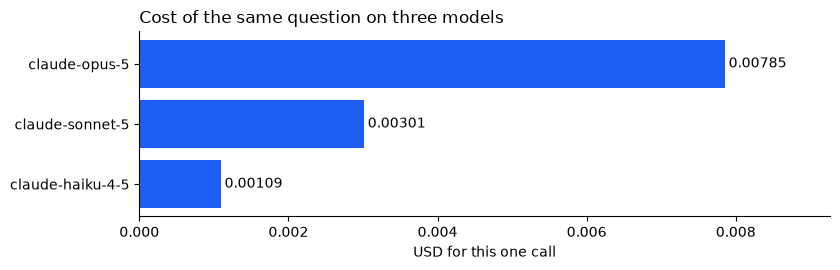

How to read it: one bar per model, same document and same question; a longer bar is a more expensive call. The input tokens differ too, because each model family tokenizes the same text differently.


In [8]:
barh(COMPARISON.index, COMPARISON["cost USD"], "Cost of the same question on three models", "USD for this one call", fmt="{:.5f}")
print("How to read it: one bar per model, same document and same question; a longer bar is a more expensive call. "
      "The input tokens differ too, because each model family tokenizes the same text differently.")

Same document, same question, three prices. Choosing a model is an engineering decision with three inputs:

- **Capability**: can it do the task at all, and does it accept the parameters your harness relies on (structured outputs, effort, a long context)? Read it from the Models API, as above.
- **Cost**: the two prices per million tokens, times your real usage. A model that costs five times more per token is not five times more expensive if it needs fewer turns; section 3 measures turns.
- **Latency**: seconds per call, which multiplies by the number of turns in a loop.

This module routes by role: main agents run on `claude-opus-5`, and workers, judges, routers and planners run on `claude-sonnet-5`. Anthropic's multi-agent research system does the same, a large model plans and synthesizes while smaller, cheaper models do the parallel legwork (Anthropic, "How we built our multi-agent research system", 13 Jun 2025). Notebook 03 builds a router that sends each task to the right model.

## 2. Context is a budget

> **Context** is everything the model sees in one call: the system prompt, instruction files, the conversation so far, tool results, retrieved documents and notes. **Context engineering** is deciding what goes in, what stays out, and when to summarize. In plain words: the dashboard shows only what fits on it, and a driver who has to scan forty gauges misses the one that matters.

In June 2025 the industry stopped saying "prompt engineering" and started saying "context engineering": "the delicate art and science of filling the context window with just the right information for the next step" (Andrej Karpathy, 25 Jun 2025). The reason is practical. A model's context window is finite (the table in section 1 shows one million tokens for the two large models), and models perform worse as the window fills with material that is not needed. Anthropic's "Effective context engineering for AI agents" (29 Sep 2025) names three techniques for long tasks, and this notebook does the first two for real:

- **Compaction**: when the conversation grows, summarize the older part into one note and continue with the summary plus the most recent turns.
- **Structured note-taking**: write facts to a file *outside* the window, so they survive compaction and restarts.
- **Sub-agent architectures**: give each focused task a fresh context and let it return a short summary (notebook 04).

One more piece of context you will meet in every real harness: **instruction files** such as `CLAUDE.md` or `AGENTS.md`, standing rules loaded into every session. Marmelab's 2026 survey found that human-written instruction files improved success by about four percent, while machine-generated ones did worse than no file at all. When everything is marked important, nothing is (Marmelab, "The State of AI Harness Engineering 2026", 24 Sep 2026). The lab writes one.

### 2.1 Counting tokens before you spend them

> A **token** is the unit models read and bill by, roughly four characters of English text. Each model family has its own tokenizer, so the same text has a different count on different models. The API has an endpoint for exact counts, `client.messages.count_tokens`, and it is free.

We count the pieces of a request one at a time: an almost empty request, then with the system prompt, then with the two tool schemas, then with the README of this repository as a tool result would carry it.

In [9]:
TOOL_SCHEMAS = [LIST_FILES.schema, READ_FILE.schema]


def count(system=None, tools=None, messages=None, model=MAIN_MODEL) -> int:
    kwargs = {"model": model, "messages": messages or [{"role": "user", "content": "hi"}]}
    if system:
        kwargs["system"] = system
    if tools:
        kwargs["tools"] = tools
    return client.messages.count_tokens(**kwargs).input_tokens


README_TEXT = read_file("README.md")
base = count()
with_system = count(system=SYSTEM)
with_tools = count(system=SYSTEM, tools=TOOL_SCHEMAS)
with_readme = count(system=SYSTEM, tools=TOOL_SCHEMAS, messages=[{"role": "user", "content": README_TEXT}])

PIECES = pd.DataFrame([
    {"piece of the request": "an almost empty request (the word 'hi')", "tokens": base},
    {"piece of the request": "the system prompt", "tokens": with_system - base},
    {"piece of the request": "the two tool schemas (with the API's tool-use preamble)", "tokens": with_tools - with_system},
    {"piece of the request": "README.md as read_file returns it (12,000 characters)", "tokens": with_readme - with_tools},
    {"piece of the request": "total", "tokens": with_readme},
]).set_index("piece of the request")
readme_counts = {model: count(messages=[{"role": "user", "content": README_TEXT}], model=model) - count(model=model)
                 for model in [MAIN_MODEL, WORKER_MODEL, SMALL_MODEL]}
record("pieces", PIECES["tokens"].to_dict())
record("readme_counts", readme_counts)
print("The same README text counts " + ", ".join(f"{n:,} tokens on {model}" for model, n in readme_counts.items()) + ".")
PIECES

The same README text counts 4,777 tokens on claude-opus-5, 4,777 tokens on claude-sonnet-5, 3,557 tokens on claude-haiku-4-5.


,tokens
piece of the request,
an almost empty request (the word 'hi'),8
the system prompt,87
the two tool schemas (with the API's tool-use preamble),609
"README.md as read_file returns it (12,000 characters)",4777
total,5481


Two things to notice. The first tool you add is not cheap: the API prepends its own instructions about how to call tools, so the two small schemas weigh far more than their text. And one file read costs several times the whole system prompt. That tool result then stays in the conversation for every later call of the session, which is why a long session grows quickly. The last line shows that the two large models count the same text identically (4,777 tokens: they share a tokenizer), while `claude-haiku-4-5` counts it as 3,557 tokens. Counts are model-specific, so always count with the model you will call.

### 2.2 A five-question session, and how it grows

We run one agent on `claude-sonnet-5` (the worker model, at low effort) through five questions about the repository in a row, passing the growing history from one question to the next, exactly as a chat application does. The loop prints every tool call; we record the real `input_tokens` of every model call.

In [10]:
QUESTIONS = [
    "Which Python version does the notebook workflow install?",
    "How many notebooks does that workflow's execute job list in its matrix?",
    "Which licence does the repository use?",
    "What test accuracy does the README report for the Module 2 survival model?",
    "What is the most recent dated entry in the CHANGELOG, and what changed?",
]

history, calls, session_runs = [], [], []
for number, question in enumerate(QUESTIONS, 1):
    print(f"\nQ{number}: {question}")
    result = run_agent(question, [LIST_FILES, READ_FILE], model=WORKER_MODEL, effort="low",
                       history=history, max_turns=5)
    history = result.messages
    session_runs.append(result)
    for u in result.usages:
        calls.append({"question": number, "call": len(calls) + 1, "prompt tokens": u.input_tokens, "output tokens": u.output_tokens})
    print(f"A{number}: {result.answer}")
    print(f"    {result.summary()}")

SESSION = pd.DataFrame(calls)
record("session", {"calls": len(SESSION), "first_prompt": int(SESSION["prompt tokens"].iloc[0]), "last_prompt": int(SESSION["prompt tokens"].iloc[-1]),
                   "messages": len(history), "cost": round(sum(r.cost for r in session_runs), 4)})
print(f"\nSession total: {len(SESSION)} model calls, {SESSION['prompt tokens'].sum():,} prompt tokens, "
      f"{sum(r.cost for r in session_runs):.4f} USD; the history now holds {len(history)} messages.")


Q1: Which Python version does the notebook workflow install?


  turn 1: list_files({"folder": ".github/workflows"}) -> OK 'ci.yml harness.yml notebooks.yml pages.yml'


  turn 2: read_file({"path": ".github/workflows/notebooks.yml"}) -> OK 'name: Execute notebooks  # Every notebook is run top to bottom in a cl'


A1: The notebook workflow installs Python **3.12** (`python-version: "3.12"`) in both the `execute` and `module-5` jobs.

Source: .github/workflows/notebooks.yml
    3 model calls | 2 tool calls | 3,828 in / 179 out | 0.0094 USD | 4.1 s | stopped: end_turn

Q2: How many notebooks does that workflow's execute job list in its matrix?


A2: The `execute` job's matrix lists **9 notebooks** (3 from M1, 3 from M2, and 3 from M3 - Descriptive analytics, Machine Learning, and ML Architectures and Deployment respectively).

Source: .github/workflows/notebooks.yml
    1 model calls | 0 tool calls | 2,265 in / 131 out | 0.0058 USD | 1.8 s | stopped: end_turn

Q3: Which licence does the repository use?


...

A3: The repository uses the **MIT License** (Copyright (c) 2026 Juan Martin Maglione).

Source: LICENSE
    3 model calls | 2 tool calls | 8,213 in / 145 out | 0.0179 USD | 4.5 s | stopped: end_turn

Q4: What test accuracy does the README report for the Module 2 survival model?


  turn 1: read_file({"path": "README.md"}) -> OK '# Fontys Tech Exercises  [![CI](https://github.com/maglionejm/fontys-t'


A4: The README reports a **test accuracy of 0.838** for the Module 2 survival model ("Module 2 trains a model that predicts who survives and judges it honestly on rows it never saw (test accuracy 0.838)").

Source: README.md
    2 model calls | 1 tool calls | 11,343 in / 129 out | 0.0240 USD | 3.0 s | stopped: end_turn

Q5: What is the most recent dated entry in the CHANGELOG, and what changed?


  turn 1: read_file({"path": "CHANGELOG.md"}) -> OK '# Changelog  All notable changes to this repository. Dates are in ISO '


A5: The most recent **dated** entry in the CHANGELOG is **2026-09-20**, under "Changed":

> "Session 1 and 2 decks enriched: AI/ML/DL landscape, rules-versus-data flip, a timeline of the field, where labels come from, sample-to-population bridge (Session 1); data-to-information ladder, data cascades, data-quality dimensions and re-identification (Session 2). All new diagrams drawn natively, all numbers sourced."

(Note: there is also an "Unreleased" section above it with newer changes, such as the Module 5 Harness Engineering additions and README rewrite, but it has no specific date.)

Source: CHANGELOG.md
    2 model calls | 1 tool calls | 17,460 in / 326 out | 0.0382 USD | 5.4 s | stopped: end_turn

Session total: 11 model calls, 43,109 prompt tokens, 0.0953 USD; the history now holds 22 messages.


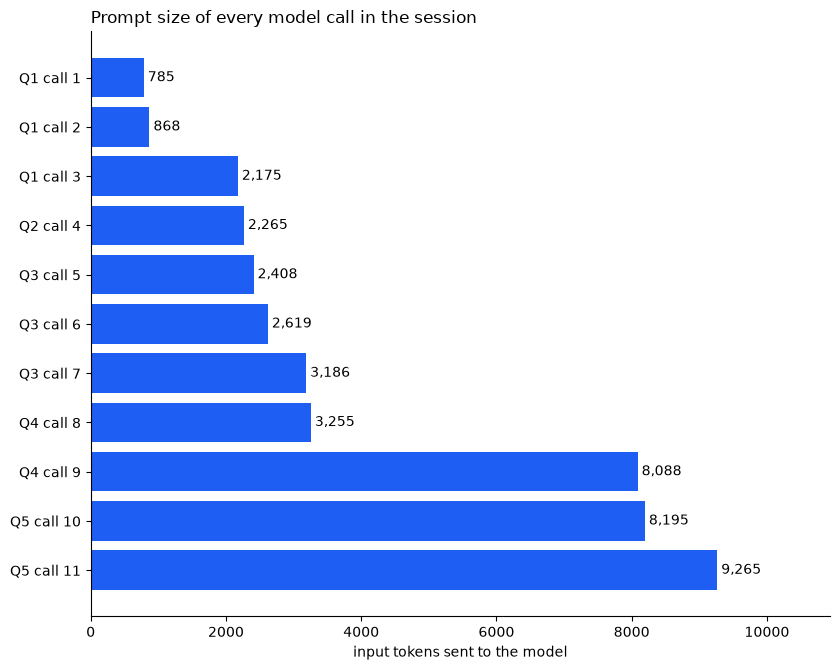

How to read it: one bar per model call, in order. Each bar is the whole conversation so far, including every earlier tool result, so the bars grow even when a question is short. Steps up mark the calls that follow a file read.


In [11]:
labels = [f"Q{row.question} call {row.call}" for row in SESSION.itertuples()]
barh(labels, SESSION["prompt tokens"], "Prompt size of every model call in the session", "input tokens sent to the model")
print("How to read it: one bar per model call, in order. Each bar is the whole conversation so far, including every earlier "
      "tool result, so the bars grow even when a question is short. Steps up mark the calls that follow a file read.")

Every call re-sends everything before it. The steps in the chart are file reads entering the conversation and staying there. Five questions are harmless; fifty would not be, and an agent that reads a dozen files per task reaches a large context in minutes. Two techniques keep a long session alive.

### 2.3 Compaction, done the real way

Compaction replaces the older part of the conversation with a summary written by a model, and keeps the most recent turns verbatim. Here we do it by hand with three steps so you see each one: split the history at the last question, ask `claude-sonnet-5` to summarize the older part (facts, sources, files already read; drop raw file contents), and rebuild the message list with the summary in front. `count_tokens` measures before and after.

The API can also do this for you: the two large models support a server-side compaction edit (the `server compaction` column in section 1, a beta feature). Doing it once by hand shows what that feature does to your conversation.

In [12]:
def render(messages) -> str:
    # Turn a message list (with SDK block objects inside) into plain text for the summarizer.
    lines = []
    for message in messages:
        content = message["content"]
        if isinstance(content, str):
            lines.append(f"{message['role']}: {content}")
            continue
        for block in content:
            b = block if isinstance(block, dict) else block.model_dump()
            if b.get("type") == "text":
                lines.append(f"{message['role']}: {b['text']}")
            elif b.get("type") == "tool_use":
                lines.append(f"assistant calls {b['name']}({json.dumps(b['input'])})")
            elif b.get("type") == "tool_result":
                body = b["content"] if isinstance(b["content"], str) else json.dumps(b["content"])
                lines.append(f"tool result ({len(body):,} chars): {body[:400]} ...")
    return "\n".join(lines)


# 1. Split: everything before the last question is "old"; the last question and its answer stay verbatim.
cut = max(i for i, m in enumerate(history) if m["role"] == "user" and isinstance(m["content"], str))
old, recent = history[:cut], history[cut:]

# 2. Summarize the old part with the worker model.
SUMMARY_PROMPT = ("Below is the transcript of a research session about a code repository. Write a compact summary that keeps "
                  "every fact found with the file it came from, the list of files already read, and any open question. "
                  "Drop the raw file contents. Use short bullet points.\n\n")
summary_response = call_model(model=WORKER_MODEL, max_tokens=600, output_config={"effort": "low"},
                              messages=[{"role": "user", "content": SUMMARY_PROMPT + render(old)}])
summary = text_of(summary_response)
show_usage(summary_response, WORKER_MODEL)

# 3. Rebuild: the summary becomes the first exchange, the recent turns follow unchanged.
compacted = [{"role": "user", "content": "[Summary of the earlier part of this session]\n" + summary},
             {"role": "assistant", "content": "Understood. I will continue from this summary."}] + recent

before = count(system=SYSTEM, tools=TOOL_SCHEMAS, messages=history)
after = count(system=SYSTEM, tools=TOOL_SCHEMAS, messages=compacted)
record("compaction", {"before": before, "after": after, "messages_before": len(history), "messages_after": len(compacted)})
print(f"\nBefore compaction: {len(history)} messages, {before:,} tokens.  After: {len(compacted)} messages, {after:,} tokens "
      f"({100 * (before - after) / before:.0f}% smaller).\n")
print("THE SUMMARY THE MODEL WROTE:\n" + summary)

usage: 1,296 input tokens, 586 output tokens, stop_reason='end_turn', cost 0.0085 USD



Before compaction: 22 messages, 9,465 tokens.  After: 6 messages, 2,681 tokens (72% smaller).

THE SUMMARY THE MODEL WROTE:
**Summary of findings:**

- `.github/workflows/notebooks.yml`:
  - Installs Python 3.12 (`python-version: "3.12"`) in both `execute` and `module-5` jobs.
  - Module 5 job requires `ANTHROPIC_API_KEY` secret, skips cleanly without it.
  - `execute` job matrix lists 9 notebooks total (3 each from M1 - Descriptive analytics, M2 - Machine Learning, M3 - ML Architectures and Deployment).

- `LICENSE`: MIT License, Copyright (c) 2026 Juan Martin Maglione.

- `README.md`: Reports Module 2 survival model test accuracy of 0.838 ("judges it honestly on rows it never saw").

**Files already read:**
- `.github/workflows/notebooks.yml`
- `LICENSE`
- `README.md`

**Files listed (not read):**
- Root directory (`.`) listing: includes `.github/`, `CHANGELOG.md`, `CODE_OF_CONDUCT.md`, `CONTRIBUTING.md`, `LICENSE`, `M1 - Descriptive analytics/`, `M2 - Machine Learning/`, `M3 - ML A

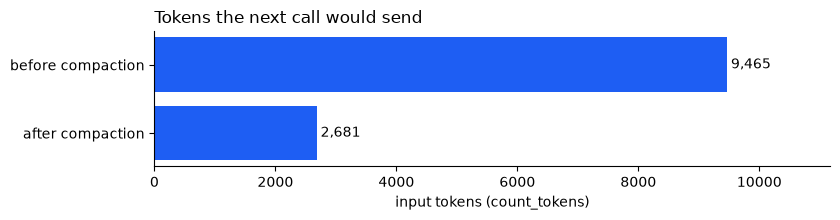

How to read it: the same session measured twice with count_tokens; the second bar keeps the last question verbatim and replaces everything older with the summary above.


In [13]:
barh(["before compaction", "after compaction"], [before, after], "Tokens the next call would send", "input tokens (count_tokens)")
print("How to read it: the same session measured twice with count_tokens; the second bar keeps the last question verbatim "
      "and replaces everything older with the summary above.")

Does the session still work on the summary? Ask a sixth question that can only be answered from memory of the earlier turns.

In [14]:
sixth = run_agent("Without reading any file: which files did you read earlier in this session, and what did each one tell us?",
                  [LIST_FILES, READ_FILE], model=WORKER_MODEL, effort="low", history=compacted, max_turns=3)
print(sixth.answer)
print("\n" + sixth.summary())

Based on the earlier part of this session (before this message), I read three files:

1. **`.github/workflows/notebooks.yml`** — Told us it installs Python 3.12 in both the `execute` and `module-5` jobs; the `module-5` job requires an `ANTHROPIC_API_KEY` secret and skips cleanly without it; and the `execute` job's matrix covers 9 notebooks total (3 each from M1 - Descriptive analytics, M2 - Machine Learning, M3 - ML Architectures and Deployment).

2. **`LICENSE`** — Told us the repository is under the MIT License, copyright (c) 2026 Juan Martin Maglione.

3. **`README.md`** — Told us the Module 2 survival model reports a test accuracy of 0.838, described as being judged "honestly on rows it never saw."

(I also read `CHANGELOG.md` in this current turn, but that was after this session summary, not "earlier.")

1 model calls | 0 tool calls | 2,781 in / 319 out | 0.0088 USD | 4.4 s | stopped: end_turn


The model answers from the summary. In the run recorded here, compaction cut the next prompt from 9,465 to 2,681 tokens (72% smaller) and the message list from 22 to 6 entries, and the sixth answer still names every file and fact. Compaction is lossy on purpose: what the summary drops is gone for good, and the quality of the summarizing prompt (keep decisions, facts and sources; drop redundant output) is one of the things context engineering is about.

### 2.4 Notes that live outside the window

A fact buried in a summarized tool result may be gone for good. **Structured note-taking**, also called agentic memory, writes the facts that matter to a place outside the context window. You do not need a special feature for it: two ordinary tools are enough, `write_note` appends one line to a file and `read_notes` returns the file. The agent calls them like any other tool. The notes file lives in the system's temporary folder, not in the conversation.

In [15]:
import tempfile

NOTES_FILE = Path(tempfile.gettempdir()) / "m5-notebook-02-notes.md"
NOTES_FILE.write_text("")     # start from an empty notes file every run


def write_note(text: str) -> str:
    with NOTES_FILE.open("a", encoding="utf-8") as f:
        f.write(text.strip() + "\n")
    return f"saved; the file now holds {len(NOTES_FILE.read_text().splitlines())} note(s)"


def read_notes() -> str:
    return NOTES_FILE.read_text(encoding="utf-8").strip() or "(no notes yet)"


WRITE_NOTE = Tool({
    "name": "write_note",
    "description": "Append one fact to the persistent notes file, which survives compaction and new sessions. Call it as soon as you have confirmed a fact worth keeping. Write one fact per call and end it with the source file in parentheses.",
    "input_schema": {"type": "object", "properties": {"text": {"type": "string", "description": "One sentence, for example 'The repository uses the MIT licence (LICENSE)'"}}, "required": ["text"]},
}, write_note)

READ_NOTES = Tool({
    "name": "read_notes",
    "description": "Return every note saved so far in the persistent notes file. Call it at the start of a task to reuse facts found in earlier sessions.",
    "input_schema": {"type": "object", "properties": {}},
}, read_notes)

taking_notes = run_agent(
    "Find out which licence this repository uses and which Python version its notebook workflow installs. "
    "Save each confirmed fact as one note with its source file, then answer.",
    [LIST_FILES, READ_FILE, WRITE_NOTE, READ_NOTES])
print("\n" + taking_notes.answer)
print("\n" + taking_notes.summary())
print("\nTHE NOTES FILE NOW HOLDS:\n" + read_notes())

  turn 1: read_notes({}) -> OK '(no notes yet)'
  turn 1: list_files({"folder": "."}) -> OK '.github/ CHANGELOG.md CODE_OF_CONDUCT.md CONTRIBUTING.md LICENSE M1 - '


  turn 2: read_file({"path": "LICENSE"}) -> OK 'MIT License  Copyright (c) 2026 Juan Martin Maglione  Permission is he'
  turn 2: list_files({"folder": ".github/workflows"}) -> OK 'ci.yml harness.yml notebooks.yml pages.yml'


  turn 3: read_file({"path": ".github/workflows/notebooks.yml"}) -> OK 'name: Execute notebooks  # Every notebook is run top to bottom in a cl'


  turn 4: write_note({"text": "The repository is licensed under the MIT License, copyright (c) 2026 Juan Martin Maglione (LICENSE)"}) -> OK 'saved; the file now holds 1 note(s)'
  turn 4: write_note({"text": "The notebook workflow installs Python \"3.12\" via actions/setup-python@v7 in both the 'execute' and 'module-5' jobs (.github/workflows/notebooks.yml)"}) -> OK 'saved; the file now holds 2 note(s)'



Both facts are confirmed and saved:

**Licence:** The repository uses the **MIT License**, with the notice `Copyright (c) 2026 Juan Martin Maglione`.

**Python version:** The notebook workflow ("Execute notebooks") installs Python `"3.12"`. It is set via `actions/setup-python@v7` with `python-version: "3.12"` and `cache: pip`, in *both* jobs — the matrix `execute` job (M1–M3 notebooks) and the `module-5` job that runs against real Claude models.

Source: LICENSE, .github/workflows/notebooks.yml

5 model calls | 7 tool calls | 11,222 in / 669 out | 0.0728 USD | 12.3 s | stopped: end_turn

THE NOTES FILE NOW HOLDS:
The repository is licensed under the MIT License, copyright (c) 2026 Juan Martin Maglione (LICENSE)
The notebook workflow installs Python "3.12" via actions/setup-python@v7 in both the 'execute' and 'module-5' jobs (.github/workflows/notebooks.yml)


Now the real test: a **fresh session** with an empty history. The conversation knows nothing, but the notes file does.

In [16]:
fresh = run_agent("What facts were saved in the notes during earlier sessions? Use read_notes and do not open any other file.",
                  [LIST_FILES, READ_FILE, WRITE_NOTE, READ_NOTES], max_turns=3)
print("\n" + fresh.answer)
print("\n" + fresh.summary())
record("notes", {"notes_lines": len(read_notes().splitlines()), "fresh_tokens": fresh.input_tokens})

  turn 1: read_notes({}) -> OK 'The repository is licensed under the MIT License, copyright (c) 2026 J'



Two facts were saved in earlier sessions:

1. "The repository is licensed under the MIT License, copyright (c) 2026 Juan Martin Maglione" (LICENSE)
2. "The notebook workflow installs Python "3.12" via actions/setup-python@v7 in both the 'execute' and 'module-5' jobs" (.github/workflows/notebooks.yml)

Source: persistent notes file (via read_notes); the cited sources within the notes are LICENSE and .github/workflows/notebooks.yml.

2 model calls | 1 tool calls | 2,096 in / 205 out | 0.0156 USD | 4.5 s | stopped: end_turn


A few dozen tokens on a file, and they survive any number of compactions or a brand-new context. This is the mechanism behind memory features in coding agents: Claude Code's `CLAUDE.md` and its auto-memory are notes outside the window that get read back in. `write_note` changes something outside the conversation, which is why section 3 will give tools like it a risk level.

## 3. Tools are prompt engineering for machines

> A **tool** is a function the model can ask for by name, with JSON arguments; the harness runs it and pastes the result back. In plain words: the steering and the pedals. The engine does not turn the wheels by itself; it asks, and the car's machinery does it.

The model never runs anything. It reads a list of tool descriptions, decides to ask for one, and receives whatever text your code sends back. So the description is the whole interface: it is the only thing the model knows about the tool. Anthropic's "Writing effective tools for agents" (Sep 2025) treats tool design as prompt engineering for machines: say *when* to use the tool and what it returns; group related tools under a shared prefix; return meaningful context, not raw dumps; keep results token-efficient by filtering, truncating and paginating.

### 3.1 Anatomy of a schema

A tool definition has three parts, and the API expects exactly this shape: a `name`, a `description`, and an `input_schema` in JSON Schema. Here is `read_file` as the model reads it.

In [17]:
print(json.dumps(READ_FILE.schema, indent=2))
one_tool = count(tools=[READ_FILE.schema]) - count()
two_tools = count(tools=TOOL_SCHEMAS) - count()
record("tool_tokens", {"one": one_tool, "two": two_tools})
print(f"\nThis one tool adds {one_tool} tokens to every call; both tools together add {two_tools}. "
      f"The first tool carries the API's tool-use preamble, the second only its own text.")

{
  "name": "read_file",
  "description": "Return the text of one file of the course repository (text files only, at most 12,000 characters). Call it to check a fact instead of guessing, then cite the path in your answer.",
  "input_schema": {
    "type": "object",
    "properties": {
      "path": {
        "type": "string",
        "description": "Repository-relative file path, for example 'README.md' or '.github/workflows/notebooks.yml'"
      }
    },
    "required": [
      "path"
    ]
  }
}



This one tool adds 438 tokens to every call; both tools together add 609. The first tool carries the API's tool-use preamble, the second only its own text.


Three parts, three jobs. The **name** is a verb phrase the model will use in its reasoning (`read_file`, not `rf`). The **description** answers three questions: what does it do, when should I call it, what comes back. The **input_schema** describes every argument with a type and a description, marks which are `required`, and uses `enum` where a value comes from a fixed set. Everything in this block sits in the context of every call, so an unused tool is never free.

### 3.2 The vague tool experiment

Here is the same file-reading function described badly. `lookup` runs exactly the code of `read_file`, but the model reads a one-word description and an argument called `q` with no explanation. We ask the same question twice on `claude-opus-5`, once with `list_files` plus `lookup`, once with `list_files` plus `read_file`, and record what happens. This is a live experiment: read the two traces before reading the table.

In [18]:
def lookup(q: str) -> str:
    return read_file(q)


LOOKUP = Tool({
    "name": "lookup",
    "description": "Searches.",
    "input_schema": {"type": "object", "properties": {"q": {"type": "string"}}, "required": ["q"]},
}, lookup)

TOOL_QUESTION = "Which Python version does the notebook workflow of this repository install? Name the file you found it in."

print("WITH THE VAGUE TOOL (list_files + lookup):")
vague = run_agent(TOOL_QUESTION, [LIST_FILES, LOOKUP], max_turns=6)
print("answer:", vague.answer)
print(vague.summary())

print("\nWITH THE CLEAR TOOL (list_files + read_file):")
clear = run_agent(TOOL_QUESTION, [LIST_FILES, READ_FILE], max_turns=6)
print("answer:", clear.answer)
print(clear.summary())

WITH THE VAGUE TOOL (list_files + lookup):


  turn 1: list_files({"folder": "."}) -> OK '.github/ CHANGELOG.md CODE_OF_CONDUCT.md CONTRIBUTING.md LICENSE M1 - '
  turn 1: lookup({"q": "python-version notebook workflow"}) -> ERROR "Error: 'python-version notebook workflow' does not exist; call list_fi"


  turn 2: list_files({"folder": ".github"}) -> OK 'CODEOWNERS ISSUE_TEMPLATE/ PULL_REQUEST_TEMPLATE.md dependabot.yml wor'


  turn 3: list_files({"folder": ".github/workflows"}) -> OK 'ci.yml harness.yml notebooks.yml pages.yml'


  turn 4: lookup({"q": ".github/workflows/notebooks.yml"}) -> OK 'name: Execute notebooks  # Every notebook is run top to bottom in a cl'


answer: The notebook workflow installs Python **`"3.12"`**.

It appears in both jobs of the "Execute notebooks" workflow (`execute` and `module-5`), each using `actions/setup-python@v7` with:

```yaml
with:
  python-version: "3.12"
  cache: pip
```

Source: .github/workflows/notebooks.yml
5 model calls | 5 tool calls | 6,474 in / 399 out | 0.0423 USD | 19.1 s | stopped: end_turn

WITH THE CLEAR TOOL (list_files + read_file):


  turn 1: list_files({"folder": "."}) -> OK '.github/ CHANGELOG.md CODE_OF_CONDUCT.md CONTRIBUTING.md LICENSE M1 - '
  turn 1: list_files({"folder": ".github/workflows"}) -> OK 'ci.yml harness.yml notebooks.yml pages.yml'


  turn 2: read_file({"path": ".github/workflows/notebooks.yml"}) -> OK 'name: Execute notebooks  # Every notebook is run top to bottom in a cl'


answer: The notebook workflow installs Python **`"3.12"`**.

Both jobs in the workflow (`execute` and `module-5`) use `actions/setup-python@v7` with:

```yaml
        with:
          python-version: "3.12"
          cache: pip
```

Source: .github/workflows/notebooks.yml
3 model calls | 3 tool calls | 4,207 in / 284 out | 0.0281 USD | 5.4 s | stopped: end_turn


In [19]:
def row_for(name, r):
    return {"tools": name, "model calls": r.turns, "tool calls": len(r.tool_calls),
            "failed tool calls": sum(1 for _, _, _, status in r.tool_calls if status != "ok"),
            "input tokens": r.input_tokens, "output tokens": r.output_tokens, "cost USD": round(r.cost, 4),
            "seconds": round(r.seconds, 1), "names the file": "notebooks.yml" in r.answer, "gives 3.12": "3.12" in r.answer}


VAGUE_VS_CLEAR = pd.DataFrame([row_for("vague (lookup)", vague), row_for("clear (read_file)", clear)]).set_index("tools")
record("vague", VAGUE_VS_CLEAR.to_dict("index"))
VAGUE_VS_CLEAR

,model calls,tool calls,failed tool calls,input tokens,output tokens,cost USD,seconds,names the file,gives 3.12
tools,,,,,,,,,
vague (lookup),5,5,1,6474,399,0.0423,19.1,True,True
clear (read_file),3,3,0,4207,284,0.0281,5.4,True,True


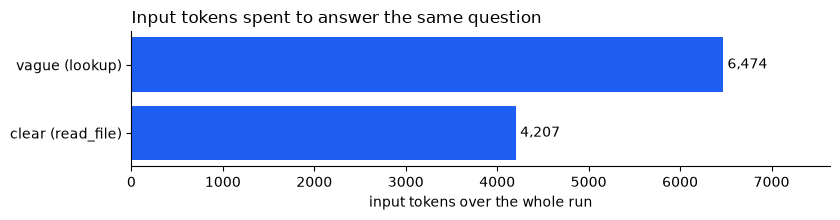

How to read it: one bar per tool set; the same question and model. A longer bar means more or larger turns were needed before the model could answer.


In [20]:
barh(VAGUE_VS_CLEAR.index, VAGUE_VS_CLEAR["input tokens"], "Input tokens spent to answer the same question", "input tokens over the whole run")
print("How to read it: one bar per tool set; the same question and model. A longer bar means more or larger turns were "
      "needed before the model could answer.")

**What the experiment showed.** Both runs reached the right answer and named the file, so the vague description did not break the agent; it made it pay. In the run recorded here the model's first `lookup` call failed (1 failed call): reading "Searches." and an argument called `q`, it sent a search phrase, not a path, and only the error message written by our tool code told it what the function actually wanted. That guess cost 2 extra model calls (5 against 3), 2,267 extra input tokens and 0.0142 USD more, to save a few dozen tokens of description on every call. Reading `lookup`, a model has to guess what is searched, what `q` should contain and what comes back. Reading `read_file`, it knows all three. The clear description costs a few dozen tokens more on every call and saves whole wasted turns; when the wasted turn carries a long context, it is not a close call.

Two field results show how much descriptions matter at scale. When Anthropic launched its web search tool, the model kept appending the year 2025 to every query; rewriting the tool description fixed it (Anthropic, "Writing effective tools for agents", Sep 2025). And fewer tools often beat more: in 2026 Vercel removed eighty percent of the tools from one of its agents, success rose from 80% to 100%, token use halved and latency fell from 724 to 141 seconds (Marmelab, "The State of AI Harness Engineering 2026", 24 Sep 2026). Every tool description sits in the context on every call, so an unused tool is not free.

### 3.3 Errors are part of the interface

When a tool fails, the model reads the failure. A Python traceback tells it nothing useful; a sentence that says what went wrong and what to try instead lets it recover in the next turn. The API has a field for exactly this: a `tool_result` block with `is_error: true`. Our loop sets it whenever the tool raised. Here is what the model receives for a path that does not exist, then a live run where the model asks for such a path and has to recover.

In [21]:
try:
    read_file("docs/README.md")
except ValueError as exc:
    error_result = {"type": "tool_result", "tool_use_id": "toolu_example", "content": f"Error: {exc}", "is_error": True}
print(json.dumps(error_result, indent=2))

{
  "type": "tool_result",
  "tool_use_id": "toolu_example",
  "content": "Error: 'docs/README.md' does not exist; call list_files on its folder to see the real names",
  "is_error": true
}


In [22]:
recovering = run_agent("Read the file docs/README.md and tell me what the course site is about, in one sentence.",
                       [LIST_FILES, READ_FILE], max_turns=6)
print("\nanswer:", recovering.answer)
print(recovering.summary())
statuses = [status for _, _, _, status in recovering.tool_calls]
record("recovering", {"statuses": statuses, "turns": recovering.turns})
print("tool call statuses in order:", statuses)

  turn 1: read_file({"path": "docs/README.md"}) -> ERROR "Error: 'docs/README.md' does not exist; call list_files on its folder "
  turn 1: list_files({"folder": "."}) -> OK '.github/ CHANGELOG.md CODE_OF_CONDUCT.md CONTRIBUTING.md LICENSE M1 - '


  turn 2: list_files({"folder": "docs"}) -> OK 'app.js assets/ data/ index.html styles.css'


  turn 3: read_file({"path": "docs/index.html"}) -> OK '<!doctype html> <html lang="en" data-theme="dark"> <head>   <meta char'



answer: There is no `docs/README.md` in this repository — the `docs/` folder contains only `app.js`, `assets/`, `data/`, `index.html` and `styles.css`, so I can't quote that file.

What I can tell you from `docs/index.html` (the course site's actual page): the site is described in its meta description as "**891 passengers, twelve columns, one night in April 1912. The dataset behind nine notebooks on data analytics, machine learning and deployment, and what it teaches.**" — i.e. it's a scrollytelling page telling the story of the Titanic dataset that runs through the course's notebooks, from data cleaning to "a model running in your browser," plus "A fourth module leaves the ship to teach harness engineering for AI agents."

Source: docs/index.html
4 model calls | 4 tool calls | 9,176 in / 626 out | 0.0615 USD | 10.4 s | stopped: end_turn
tool call statuses in order: ['error', 'ok', 'ok', 'ok']


**What happened.** The first tool call asked for the file we named and came back as an error, exactly the block printed above. The model did not stop and did not invent a file: it listed the folder, found what really exists there, and answered from that, saying plainly that `docs/README.md` does not exist (4 model calls in the run recorded here). That recovery was possible because the error said what to do next. A model that reads `FileNotFoundError: [Errno 2]` has to guess; a model that reads "call list_files on its folder" has a plan. Two rules follow: never let a raw traceback reach the model, and write the error text for the reader who has to act on it, which is the model.

### 3.4 Strict tools

The model writes the JSON arguments of a tool call, and it can get them wrong: a missing required field, a number where a string belongs. Marking a tool `"strict": true` (and closing the schema with `additionalProperties: false`) makes the API guarantee that the arguments match the schema before they reach your code. It costs nothing at run time and removes one class of error handling from the loop. The two models this module uses support it (the `structured outputs` column in section 1).

In [23]:
def strict(tool: Tool) -> Tool:
    schema = json.loads(json.dumps(tool.schema))               # deep copy
    schema["strict"] = True
    schema["input_schema"]["additionalProperties"] = False
    return Tool(schema, tool.fn)


STRICT_TOOLS = [strict(LIST_FILES), strict(READ_FILE)]
print(json.dumps(STRICT_TOOLS[1].schema, indent=2))

strict_run = run_agent("Which packages does requirements.txt list under the Module 5 comment? Quote them.",
                       STRICT_TOOLS, model=WORKER_MODEL, effort="low", max_turns=4)
print("\nanswer:", strict_run.answer)
print(strict_run.summary())

{
  "name": "read_file",
  "description": "Return the text of one file of the course repository (text files only, at most 12,000 characters). Call it to check a fact instead of guessing, then cite the path in your answer.",
  "input_schema": {
    "type": "object",
    "properties": {
      "path": {
        "type": "string",
        "description": "Repository-relative file path, for example 'README.md' or '.github/workflows/notebooks.yml'"
      }
    },
    "required": [
      "path"
    ],
    "additionalProperties": false
  },
  "strict": true
}


  turn 1: list_files({"folder": "."}) -> OK '.github/ CHANGELOG.md CODE_OF_CONDUCT.md CONTRIBUTING.md LICENSE M1 - '


  turn 2: read_file({"path": "requirements.txt"}) -> OK '# Core data packages pandas numpy scipy  # Visualization matplotlib se'



answer: Under the "Module 5 (Harness Engineering)" comment, requirements.txt lists:

- `anthropic`
- `python-dotenv`
- `pyyaml`

Source: requirements.txt
3 model calls | 2 tool calls | 3,158 in / 170 out | 0.0080 USD | 4.7 s | stopped: end_turn


The request was accepted and the arguments arrived exactly as the schema describes. Strict tools do not make the model call the right tool, or call it at the right time; they make sure that what it sends can be executed.

### 3.5 A first look at gating: your code runs before the tool does

> A **guardrail** is a check that runs outside the model and cannot be talked out of. In plain words: the brakes. They work whatever the engine is doing.

Look at the `gate` argument of `run_agent`: a function your code calls with the tool name and its arguments **before** the tool runs. If it returns a reason, the tool never runs and the model receives that reason as an error result. The decision is never the model's to make. Here the policy is simple: this agent may not open the `docs/` folder, the course site. Then we ask a question whose only answer sits in `docs/data/model.json`, and watch.

In [24]:
def deny_docs_folder(tool_name: str, arguments: dict) -> str | None:
    target = arguments.get("path") or arguments.get("folder") or ""
    if Path(target).parts[:1] == ("docs",):
        return "policy forbids this agent to open the docs/ folder; use other files or report that the value is unavailable"
    return None


gated = run_agent("What ROC-AUC did the course's survival model score on the test set?",
                  [LIST_FILES, READ_FILE], gate=deny_docs_folder, max_turns=4)   # a tighter brake for this experiment
print("\nanswer:", gated.answer)
print(gated.summary())
denied = [(turn, name, args) for turn, name, args, status in gated.tool_calls if status == "denied"]
record("gated", {"denied": len(denied), "turns": gated.turns, "stopped": gated.stopped_because,
                 "mentions_0878": "0.878" in gated.answer, "answered": bool(gated.answer.strip())})
print(f"denied calls: {len(denied)}")

  turn 1: list_files({"folder": "."}) -> OK '.github/ CHANGELOG.md CODE_OF_CONDUCT.md CONTRIBUTING.md LICENSE M1 - '


  turn 2: list_files({"folder": "M2 - Machine Learning"}) -> OK '01-data-prep-and-feature-engineering.ipynb 02-model-selection.ipynb 03'
  turn 2: list_files({"folder": "docs"}) -> DENIED 'Denied: policy forbids this agent to open the docs/ folder; use other '


  turn 3: read_file({"path": "M2 - Machine Learning/02-model-selection.ipynb"}) -> OK '{  "cells": [   {    "cell_type": "markdown",    "id": "c77db1a0",    '
  turn 3: read_file({"path": "M2 - Machine Learning/03-model-optimization-and-deployment.ipynb"}) -> OK '{  "cells": [   {    "cell_type": "markdown",    "id": "fe53a625",    '


  turn 4: list_files({"folder": "presentations"}) -> OK 'README.md m2-session-1-machine-learning-fundamentals.pptx m2-session-2'
  turn 4: list_files({"folder": "M3 - ML Architectures and Deployment"}) -> OK '01-ml-system-architectures.ipynb 02-deploying-models-in-the-cloud.ipyn'

answer: 
4 model calls | 7 tool calls | 14,407 in / 523 out | 0.0851 USD | 15.8 s | stopped: max_turns
denied calls: 1


**What happened.** The gate did its job: the trace shows a `DENIED` result the moment the model reached for `docs/`, and the file was never opened (1 denied call in the run recorded here). What happened next is the honest part of this experiment. Our denial message offered two ways out, "use other files or report that the value is unavailable", and the model chose the first: it went looking through the rest of the repository, opening other files, and was still searching when the loop's `max_turns` (set to 4 for this run) stopped it after 4 calls, without a final answer. Two lessons. A gate should tell the model exactly what to do instead, not offer it a search; and `max_turns` is itself a brake, the one that catches a run that no other rule caught. Notebook 04 measures this runaway behaviour on purpose.

This is the harness equivalent of the tool safeguards with risk ratings in OpenAI's guide to building agents (OpenAI, "A practical guide to building agents", Apr 2025), and of the approval prompts you see in Claude Code. Notebook 03 turns this `gate` into proper hooks with risk levels (`read`, `write`, `danger`) and a permission rule. A warning from the field: permission prompts only help if someone reads them. Marmelab's 2026 survey found that 93% of permission prompts get approved, the "approval paradox". A rule you can write in code is worth more than a prompt a tired human clicks through.

## 4. Skills and progressive disclosure

> A **skill** is a folder with a `SKILL.md` file (name, description, instructions) and optional scripts or reference files; the agent reads the description first and opens the rest only when the task matches. In plain words: the manuals in the glovebox. Always in the car, opened only when something specific comes up.

Tools give a model abilities. Skills teach it procedures: how to use those abilities well for a recurring kind of work. Anthropic introduced Agent Skills on 16 October 2025 ("Equipping agents for the real world with Agent Skills") and published the format as an open standard on 18 December 2025; by 2026 more than forty platforms support it, Claude Code among them.

The idea that makes skills cheap is **progressive disclosure**, in three levels:

1. **Level 1, at startup:** the agent sees only each skill's name and one-line description, a few dozen tokens per skill. A library of a hundred skills costs almost nothing.
2. **Level 2, when a task matches:** the agent loads the full instructions of that one skill.
3. **Level 3, while executing:** it reads the supporting files or runs the scripts the instructions mention.

### 4.1 The standard, as a real file

The lab folder of this module, `lab/`, is a small Claude Code project. Its skills live where Claude Code looks for them, `lab/.claude/skills/<name>/SKILL.md`. Here is one, read with plain Python (the `read_file` tool refuses `.claude` folders on purpose). The block between the `---` lines is YAML front matter with the two required fields, `name` and `description`; the Markdown below it is the procedure.

In [25]:
import yaml

SKILLS_DIR = REPO_ROOT / "M5 - Harness Engineering" / "lab" / ".claude" / "skills"


def parse_skill(text: str) -> dict:
    _, front_matter, body = text.split("---", 2)
    meta = yaml.safe_load(front_matter)
    return {"name": meta["name"], "description": meta["description"], "body": body.strip()}


SKILLS = {}
for skill_file in sorted(SKILLS_DIR.glob("*/SKILL.md")):
    skill = parse_skill(skill_file.read_text(encoding="utf-8"))
    SKILLS[skill["name"]] = skill

print(f"{len(SKILLS)} skills found: {', '.join(SKILLS)}\n")
print((SKILLS_DIR / "repo-answers" / "SKILL.md").read_text(encoding="utf-8"))

2 skills found: explain-term, repo-answers

---
name: repo-answers
description: Answer a question about this repository from its files and cite the file path as the source. Use when the user asks what the project, its docs or its configuration say, or asks for a fact that should be looked up rather than remembered.
---

# Answering questions from this repository

Use this procedure whenever the answer should come from files in this project and not from memory.

## Steps

1. **Locate.** List the folder most likely to hold the answer. Course content lives in `docs/`; configuration lives at the root of the folder. Prefer reading a file over guessing what it contains.
2. **Read.** Open the file and find the exact passage. Quote it or paraphrase it faithfully. Do not round numbers or change dates.
3. **Cite.** End the answer with one line per file used, in the form `Source: docs/glossary.md`. Use the path relative to this folder.
4. **Say when it is not there.** If no file contains the answ

### 4.2 Progressive disclosure, measured on the real tokenizer

Level 1 is one line per skill: `- name: description`. Level 2 is the body. We count both with `count_tokens`, per skill, on the main model.

In [26]:
rows = []
for name, skill in SKILLS.items():
    catalog_line = f"- {name}: {skill['description']}"
    rows.append({"skill": name,
                 "level 1: catalog line (tokens)": count(messages=[{"role": "user", "content": catalog_line}]) - count(),
                 "level 2: full body (tokens)": count(messages=[{"role": "user", "content": skill["body"]}]) - count()})
SKILL_TOKENS = pd.DataFrame(rows).set_index("skill")
SKILL_TOKENS.loc["all skills"] = SKILL_TOKENS.sum()
catalog_total = int(SKILL_TOKENS.loc["all skills"].iloc[0])
body_total = int(SKILL_TOKENS.loc["all skills"].iloc[1])
record("skills", {"catalog": catalog_total, "bodies": body_total, "ratio": round(body_total / catalog_total, 1)})
print(f"Carrying the catalog on every call costs {catalog_total} tokens; carrying every body would cost {body_total}, "
      f"{body_total / catalog_total:.1f} times more.")
SKILL_TOKENS

Carrying the catalog on every call costs 152 tokens; carrying every body would cost 580, 3.8 times more.


,level 1: catalog line (tokens),level 2: full body (tokens)
skill,,
explain-term,84,274
repo-answers,68,306
all skills,152,580


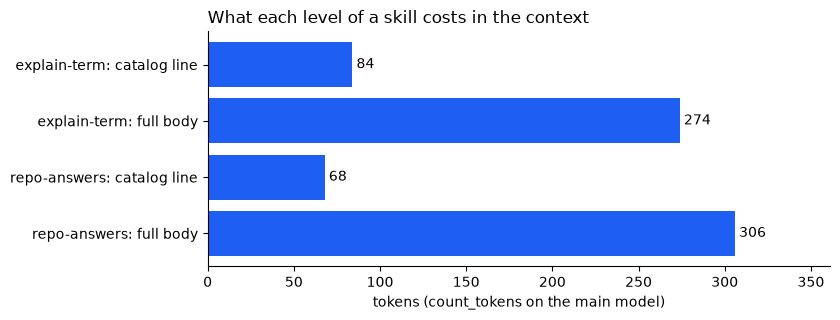

How to read it: two bars per skill. The short bar is what every call carries (level 1); the long bar is loaded only when a task matches the description (level 2).


In [27]:
labels = [f"{name}: {level}" for name in SKILLS for level in ("catalog line", "full body")]
values = [SKILL_TOKENS.loc[name, col] for name in SKILLS for col in SKILL_TOKENS.columns]
barh(labels, values, "What each level of a skill costs in the context", "tokens (count_tokens on the main model)")
print("How to read it: two bars per skill. The short bar is what every call carries (level 1); the long bar is loaded only "
      "when a task matches the description (level 2).")

In the run recorded here the catalog of both skills costs 152 tokens on every call, while carrying both bodies would cost 580 tokens, 3.8 times more. With two skills that is a saving of a few hundred tokens per call; with the fifty skills of a real project it is the difference between a cheap catalog and a system prompt nobody can afford.

### 4.3 An agent that opens the glovebox

Two additions turn a plain agent into one that uses skills. The **catalog** (level 1) is appended to the system prompt, so the model sees every name and description on every call. A **`load_skill` tool** returns the body of one skill (level 2) on demand. The model decides when to open it, the way you decide when to open the manual. We run it once on a question that matches `repo-answers` and watch the trace for the load.

In [28]:
SKILL_CATALOG = "\n".join(f"- {name}: {skill['description']}" for name, skill in SKILLS.items())
SYSTEM_WITH_SKILLS = (SYSTEM + "\n\nSkills available. When a task matches a skill's description, call load_skill with its name "
                      "before doing anything else, then follow the instructions it returns.\n" + SKILL_CATALOG)


def load_skill(name: str) -> str:
    if name not in SKILLS:
        raise ValueError(f"unknown skill {name!r}; available skills: {', '.join(SKILLS)}")
    return SKILLS[name]["body"]


LOAD_SKILL = Tool({
    "name": "load_skill",
    "description": "Load the full instructions of one skill listed in the system prompt. Call it before starting a task that matches a skill's description; the result is the procedure to follow.",
    "input_schema": {"type": "object", "properties": {"name": {"type": "string", "enum": list(SKILLS),
                                                               "description": "The skill's name exactly as listed"}}, "required": ["name"]},
}, load_skill)

skilled = run_agent("Which licence does this repository use?", [LOAD_SKILL, LIST_FILES, READ_FILE], system=SYSTEM_WITH_SKILLS)
print("\nanswer:", skilled.answer)
print(skilled.summary())
loads = [(turn, args["name"]) for turn, name, args, _ in skilled.tool_calls if name == "load_skill"]
record("skilled", {"loads": loads, "turns": skilled.turns, "tokens": skilled.input_tokens, "has_source": "Source:" in skilled.answer})
print("load_skill calls (turn, skill):", loads)

  turn 1: load_skill({"name": "repo-answers"}) -> OK '# Answering questions from this repository  Use this procedure wheneve'
  turn 1: list_files({"folder": "."}) -> OK '.github/ CHANGELOG.md CODE_OF_CONDUCT.md CONTRIBUTING.md LICENSE M1 - '


  turn 2: read_file({"path": "LICENSE"}) -> OK 'MIT License  Copyright (c) 2026 Juan Martin Maglione  Permission is he'



answer: The repository uses the "MIT License", with "Copyright (c) 2026 Juan Martin Maglione".

Source: LICENSE
3 model calls | 3 tool calls | 5,007 in / 209 out | 0.0303 USD | 6.0 s | stopped: end_turn
load_skill calls (turn, skill): [(1, 'repo-answers')]


**What the trace shows.** The first thing the model did was `load_skill('repo-answers')`: the question matched the catalog line, so it opened the manual before touching a file (in the run recorded here it listed the root folder in the same turn). Then it followed the procedure it had just read: locate, read, cite. The answer ends with a `Source:` line as the skill demands, and the whole run took 3 model calls and 5,007 input tokens, the body of the skill included in every call after the load. That is the price of a procedure the model follows reliably; in notebook 03 an eval suite measures what it buys.

### 4.4 Claude Code does this for you

What you just built by hand is exactly what Claude Code does with the `.claude/skills/` folder of a project: at startup it reads every `SKILL.md` front matter into a catalog (level 1), and when a task matches a description it loads the body (level 2) and follows it, opening any supporting files the instructions name (level 3). The lab for this session, `lab/02-lab-claude-code-skills-and-mcp.md`, runs the two skills you measured above inside Claude Code and shows the load happening.

### 4.5 Prompts, tools and skills do different jobs

| | Gives the model | Lives in | Loaded | Example in this notebook |
|---|---|---|---|---|
| **Prompt** | the task, and standing rules | the user message and the system prompt | every call | `SYSTEM` |
| **Tool** | an ability | a function with a name, a description and a schema | described every call, run on request | `read_file`, `write_note` |
| **Skill** | a procedure: how to use the abilities well for a kind of work | a folder with `SKILL.md` and optional files | name and description every call, body on demand | `repo-answers` |

A prompt without tools cannot act. Tools without a procedure get used badly. A skill without tools has nothing to instruct. The harness is what puts the three together (Anthropic, "Equipping agents for the real world with Agent Skills", 16 Oct 2025).

## 5. MCP: the standard plug

> **MCP**, the Model Context Protocol, is an open standard that lets any tool server plug into any model client. In plain words: the standard trailer hitch. The trailer does not need to know which car will tow it.

Every tool in this notebook lives in the same Python process as the loop. In real systems the tools live elsewhere: a database, a ticketing system, a browser, a company's internal API. Before MCP, every harness wrote its own connector for every tool. Anthropic open-sourced the Model Context Protocol on 25 November 2024: an **MCP server** exposes tools, resources and prompts over a common message format, and any **MCP client** (a chat application, a coding agent, your own loop) connects to it without custom integration code. OpenAI adopted MCP on 26 March 2025 in its Agents SDK, then in ChatGPT and the Responses API; by 2026 it is the default way harnesses discover and call external tools (Anthropic, "Introducing the Model Context Protocol", Nov 2024).

Everything you learned in section 3 still applies. An MCP tool is still a name, a description and a JSON schema; the client turns the server's tool list into exactly the `tools` parameter you saw above, and a bad description hurts just as much over a standard plug. Two ways to use it from Python, both in the SDK you have been using: the `mcp_servers` request parameter lets the API connect to a remote MCP server on your behalf, and the `anthropic.lib.tools.mcp` helpers convert a local server's tools for the SDK's tool runner. The lab takes the third and most common route: adding the reference filesystem MCP server to Claude Code with one command and watching its tools appear next to the built-in ones.

## 6. Key takeaways

- **The model is one request and one response.** Everything it sees is in the request; everything it made is in `content`, `stop_reason` and `usage`. Read capabilities from the Models API and choose by capability, cost and latency; route cheap models to easy steps.
- **Context is a budget.** Every tool result stays in the conversation for every later call, and `count_tokens` tells you the price before you pay it. Compaction folds the old part into a model-written summary; notes move the facts that matter out of the window altogether.
- **A tool is its description.** The model reads a name, a sentence and a JSON schema, nothing else. Vague descriptions cost turns; unused tools cost tokens on every call; error messages must tell the model what to try next; strict schemas guarantee the arguments.
- **Gates are decided outside the model.** Code that runs before the tool call cannot be talked out of. Rules in code beat prompts humans click through.
- **Skills are procedures, disclosed progressively.** A catalog line per skill on every call, the body only when a task matches. Prompts give the task, tools give abilities, skills give procedures.
- **MCP is the standard plug.** A tool over MCP is still a name, a description and a schema; the lab connects one.

## 7. Practice exercises

Try these yourself before peeking at the solutions. All four use the helpers defined above; the two that call a model use the worker model and cost a few cents.

**Exercise 1 - Write a skill.** Create a new skill folder in a temporary directory with a `SKILL.md` that follows the layout of `repo-answers`: front matter with `name` and `description`, then numbered steps. A good candidate: `count-things`, a procedure for answering "how many" questions about the repository (list, count in code, never estimate). Parse it with `parse_skill`, then count the level-1 line and the level-2 body with `count_tokens`. How many tokens does your skill add to every call?

**Exercise 2 - Tune a description.** Rewrite the vague `lookup` tool from section 3.2 with a description that says what it reads, what the argument must contain, what comes back and what to do next. Count the tokens of both schemas, then run the same question once on the worker model with your tool and compare the number of tool calls with the vague run.

**Exercise 3 - Make an error message helpful.** Write `read_file_helpful(path)` that, when the file does not exist, suggests the closest existing names in that folder (the standard library's `difflib.get_close_matches` does the matching). Show the message for a typo in a file name and for a typo in a folder name. No model call needed.

**Exercise 4 - Count what a long tool result costs.** In the session of section 2.2 one tool result was the README, which `read_file` returns in full up to 12,000 characters. Using the token count you already measured and the session table, compute how many tokens that single read added over the calls that followed it, and what those tokens cost on the worker model. Then measure the same for a version truncated to 2,000 characters.

## 8. Solutions

**Solution 1 - Write a skill.** The folder name, the `name` in the front matter and the description are all the agent sees at level 1. Keep the description to one line that says *when* the skill applies; that line is what a model matches against the task.

In [29]:
skill_root = Path(tempfile.mkdtemp(prefix="my-skills-")) / "count-things"
skill_root.mkdir(parents=True)
(skill_root / "SKILL.md").write_text(
    "---\n"
    "name: count-things\n"
    "description: Answer 'how many' questions about the repository by listing and counting, never by estimating. Use when a question asks for a number of files, notebooks, entries or lines.\n"
    "---\n"
    "# Counting things in the repository\n\n"
    "1. Locate the folder or file that holds the items with list_files.\n"
    "2. Read the file when the items are lines or entries inside it; list the folder when they are files.\n"
    "3. Count in the tool output, item by item. Do not estimate and do not round.\n"
    "4. Answer with the number, what exactly was counted, and 'Source: <path>'.\n",
    encoding="utf-8")

my_skill = parse_skill((skill_root / "SKILL.md").read_text(encoding="utf-8"))
level_1 = count(messages=[{"role": "user", "content": f"- {my_skill['name']}: {my_skill['description']}"}]) - count()
level_2 = count(messages=[{"role": "user", "content": my_skill["body"]}]) - count()
print(f"{my_skill['name']}: level 1 costs {level_1} tokens on every call; level 2 costs {level_2} tokens when loaded "
      f"({level_2 / level_1:.1f} times the catalog line).")

count-things: level 1 costs 54 tokens on every call; level 2 costs 112 tokens when loaded (2.1 times the catalog line).


**Solution 2 - Tune a description.** The better description says what is read (a repository file), what `q` must contain (a repository-relative path), what comes back (the text, capped) and what to do next (cite the path). It costs more tokens to describe and buys a model that knows what to send.

In [30]:
LOOKUP_BETTER = Tool({
    "name": "lookup",
    "description": "Read one text file of the course repository and return its content (at most 12,000 characters). Call it when you know, or have listed, the exact path of the file that holds the answer; then cite that path.",
    "input_schema": {"type": "object",
                     "properties": {"q": {"type": "string", "description": "Repository-relative file path, for example 'README.md' or '.github/workflows/notebooks.yml'"}},
                     "required": ["q"]},
}, lookup)

vague_tokens = count(tools=[LOOKUP.schema]) - count()
better_tokens = count(tools=[LOOKUP_BETTER.schema]) - count()
print(f"schema tokens: vague {vague_tokens}, tuned {better_tokens}\n")

tuned = run_agent(TOOL_QUESTION, [LIST_FILES, LOOKUP_BETTER], model=WORKER_MODEL, effort="low", max_turns=6)
print("answer:", tuned.answer)
print(tuned.summary())
print(f"\ntool calls: vague run {len(vague.tool_calls)} ({sum(1 for c in vague.tool_calls if c[3] != 'ok')} failed), "
      f"tuned run {len(tuned.tool_calls)} ({sum(1 for c in tuned.tool_calls if c[3] != 'ok')} failed)")

schema tokens: vague 351, tuned 443



  turn 1: list_files({"folder": ".github/workflows"}) -> OK 'ci.yml harness.yml notebooks.yml pages.yml'


  turn 2: lookup({"q": ".github/workflows/notebooks.yml"}) -> OK 'name: Execute notebooks  # Every notebook is run top to bottom in a cl'


answer: The notebook workflow installs Python version **"3.12"** (used via `actions/setup-python@v7` with `python-version: "3.12"` in both the main notebook execution job and the Module 5 job).

Source: .github/workflows/notebooks.yml
3 model calls | 2 tool calls | 3,882 in / 198 out | 0.0097 USD | 5.0 s | stopped: end_turn

tool calls: vague run 5 (1 failed), tuned run 2 (0 failed)


**Solution 3 - Make an error message helpful.** The function looks for near-misses in the right folder and names them. A model that reads "did you mean README.md" recovers in one turn; a model that reads "not found" has to list the folder first.

In [31]:
import difflib


def read_file_helpful(path: str) -> str:
    target = safe_path(path)
    if target.is_file():
        return read_file(path)
    folder = target.parent
    if not folder.is_dir():
        siblings = [p.name for p in folder.parent.iterdir() if p.is_dir()] if folder.parent.is_dir() else []
        close = difflib.get_close_matches(folder.name, siblings, n=3, cutoff=0.6)
        hint = f"; did you mean the folder {', '.join(close)}?" if close else ""
        raise ValueError(f"the folder of {path!r} does not exist{hint}")
    names = [p.name for p in folder.iterdir() if p.is_file()]
    close = difflib.get_close_matches(target.name, names, n=3, cutoff=0.6)
    hint = f"; did you mean {', '.join(close)}?" if close else f"; the folder holds: {', '.join(sorted(names)[:8])}"
    raise ValueError(f"{path!r} does not exist{hint}")


for typo in ["LICENCE", ".github/workflow/notebooks.yml", "CHANGELOG.txt"]:
    try:
        read_file_helpful(typo)
    except ValueError as exc:
        print(f"{typo:<35} -> Error: {exc}")

LICENCE                             -> Error: 'LICENCE' does not exist; did you mean LICENSE?
.github/workflow/notebooks.yml      -> Error: the folder of '.github/workflow/notebooks.yml' does not exist; did you mean the folder workflows?
CHANGELOG.txt                       -> Error: 'CHANGELOG.txt' does not exist; did you mean CHANGELOG.md?


**Solution 4 - Count what a long tool result costs.** A tool result is paid once when it enters the conversation and again on every later call of the session. The multiplier is the number of calls that follow it, which is why truncating, filtering and compacting matter more the longer a session runs.

In [32]:
readme_tokens = int(PIECES.loc["README.md as read_file returns it (12,000 characters)", "tokens"])
# The README was read while answering question 4; every call after that read carried it.
read_call = next(i for i, r in enumerate(session_runs, 1) if any(args.get("path") == "README.md" for _, _, args, _ in r.tool_calls))
calls_after = int((SESSION["question"] > read_call).sum()) + int((SESSION["question"] == read_call).sum()) - 1
price_in = PRICES[WORKER_MODEL][0]
full_cost = readme_tokens * (1 + calls_after) * price_in / 1_000_000

short_tokens = count(messages=[{"role": "user", "content": README_TEXT[:2000]}]) - count()
short_cost = short_tokens * (1 + calls_after) * price_in / 1_000_000

print(f"README read during question {read_call}; {calls_after} model calls followed it in the session.")
print(f"full result:      {readme_tokens:>6,} tokens x {1 + calls_after} calls = {readme_tokens * (1 + calls_after):>7,} tokens = {full_cost:.4f} USD on {WORKER_MODEL}")
print(f"truncated (2,000 chars): {short_tokens:>6,} tokens x {1 + calls_after} calls = {short_tokens * (1 + calls_after):>7,} tokens = {short_cost:.4f} USD")

README read during question 4; 3 model calls followed it in the session.
full result:       4,777 tokens x 4 calls =  19,108 tokens = 0.0382 USD on claude-sonnet-5
truncated (2,000 chars):    804 tokens x 4 calls =   3,216 tokens = 0.0064 USD


## 9. What this run cost

Every call went through `call_model`, so the ledger holds the real usage of the whole notebook.

In [33]:
bill = pd.DataFrame([{"model": model, "calls": 1, "input tokens": u.input_tokens + (u.cache_read_input_tokens or 0) + (u.cache_creation_input_tokens or 0),
                      "output tokens": u.output_tokens, "cost USD": cost_usd(u, model)} for model, u in LEDGER])
BILL = bill.groupby("model").sum(numeric_only=True)
BILL.loc["total"] = BILL.sum()
BILL["cost USD"] = BILL["cost USD"].round(4)
record("bill", BILL.to_dict("index"))
NOTES_FILE.unlink(missing_ok=True)   # tidy up the scratch notes file
print(f"This execution made {int(BILL.loc['total', 'calls'])} model calls and cost {BILL.loc['total', 'cost USD']:.4f} USD.")
BILL

This execution made 49 model calls and cost 0.4797 USD.


,calls,input tokens,output tokens,cost USD
model,,,,
claude-haiku-4-5,1.0,945.0,29.0,0.0011
claude-opus-5,28.0,53948.0,3023.0,0.3453
claude-sonnet-5,20.0,55547.0,2220.0,0.1333
total,49.0,110440.0,5272.0,0.4797
